<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[EfficientNet-B0] Epoch   1/100 | LR: 1.38e-03 | train loss 0.9208 acc 0.616 | val loss 0.6676 acc 0.680 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.38e-03 | train loss 0.6940 acc 0.728 | val loss 0.5050 acc 0.806 *


[EfficientNet-B0] Epoch   3/100 | LR: 1.38e-03 | train loss 0.6751 acc 0.752 | val loss 0.6417 acc 0.771


[EfficientNet-B0] Epoch   4/100 | LR: 1.38e-03 | train loss 0.6333 acc 0.753 | val loss 0.4926 acc 0.777 *


...

[EfficientNet-B0] Epoch  17/100 | LR: 1.38e-03 | train loss 0.3021 acc 0.902 | val loss 0.4805 acc 0.821


[EfficientNet-B0] Epoch  18/100 | LR: 1.38e-03 | train loss 0.1077 acc 0.967 | val loss 1.4809 acc 0.739


[EfficientNet-B0] Epoch  19/100 | LR: 1.38e-03 | train loss 0.1972 acc 0.954 | val loss 0.9434 acc 0.783


[EfficientNet-B0] Epoch  20/100 | LR: 1.38e-03 | train loss 0.1405 acc 0.964 | val loss 0.5473 acc 0.845


[EfficientNet-B0] Epoch  21/100 | LR: 1.38e-03 | train loss 0.0701 acc 0.983 | val loss 0.5641 acc 0.830

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 21.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.4615)


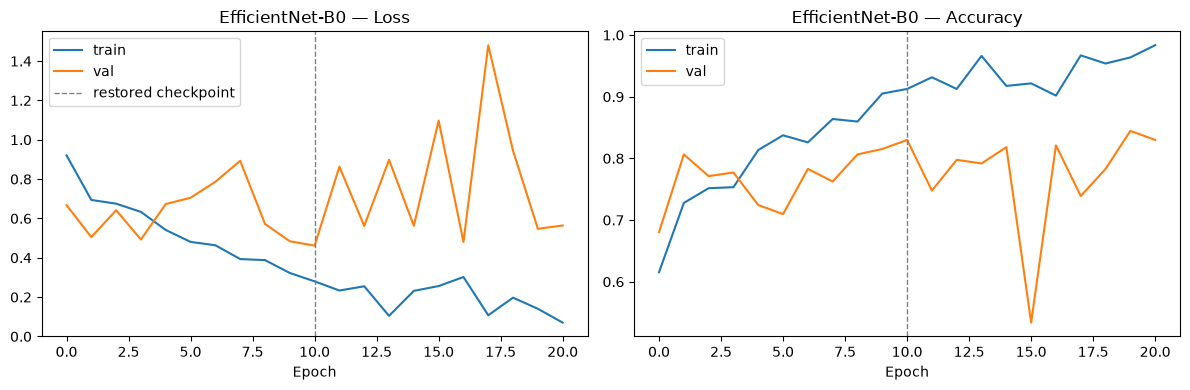

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.779


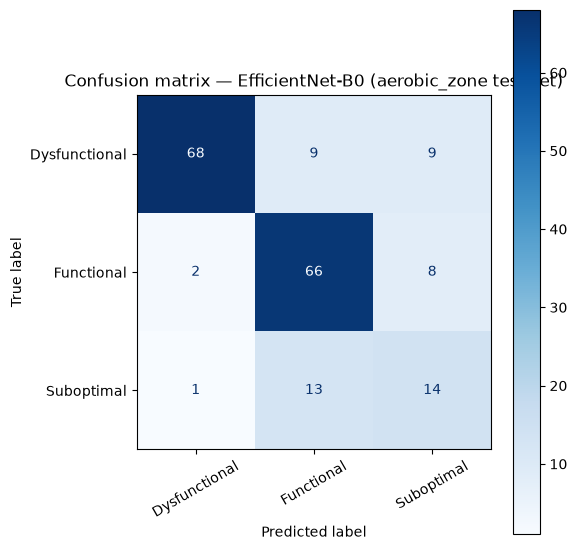

               precision    recall  f1-score   support

Dysfunctional      0.958     0.791     0.866        86
   Functional      0.750     0.868     0.805        76
   Suboptimal      0.452     0.500     0.475        28

     accuracy                          0.779       190
    macro avg      0.720     0.720     0.715       190
 weighted avg      0.800     0.779     0.784       190



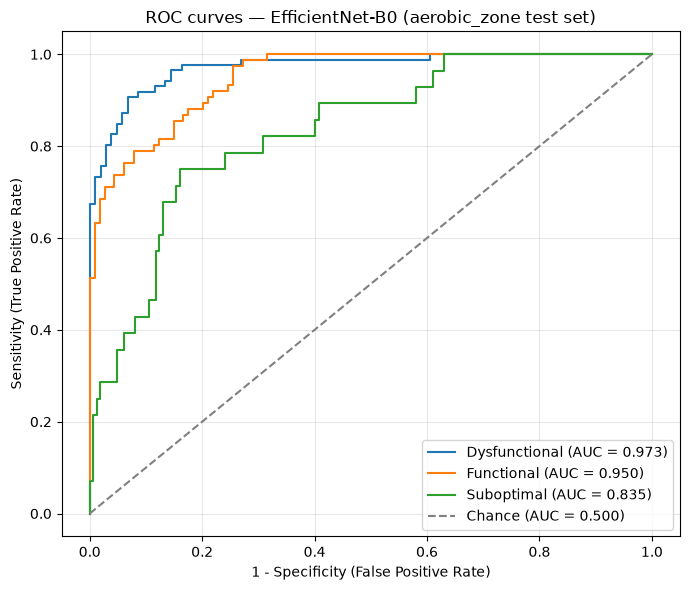

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.973
  Functional     : 0.950
  Suboptimal     : 0.835

Mean AUC (over 3/3 classes with test examples): 0.919


(np.float64(0.7789473684210526),
 {'Dysfunctional': 0.9726073345259392,
  'Functional': 0.9496768236380424,
  'Suboptimal': 0.8346560846560847})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/aerobic_zone_noaug/results_aerobic_zone_efficientnet_b0_stratified.pkl


Saved model weights to ../models/aerobic_zone_efficientnet_b0_cnn.pt
